# Ethan Varner
Assistance from ChatGPT as described below



## Imports and Setup

In [ ]:
# ChatGPT assisted with some code, concepts, and formatting of output, along with the graphical analysis to make things look better
from __future__ import print_function

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Data Loading and Augmentation


In [ ]:
print('Preparing CIFAR-10 data')

# CIFAR-10 channel mean and std
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

# training transforms augmentation to reduce overfitting
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter( # color variation
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
    ),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# test transforms. normalize only, no augmentation
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# download and load datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

print(f'Training samples: {len(trainset)}')
print(f'Test samples: {len(testset)}')
print(f'Classes: {trainset.classes}')

Preparing CIFAR-10 data
Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Model Architecture — ImprovedNet


In [ ]:
class ImprovedNet(nn.Module):

    # VGG-style CNN for CIFAR-10 with Batch Normalization and Dropout.
    # Here is the layout
    # Block 1: Conv1(3->64) -> BN -> ReLU -> Conv2(64->64) -> BN -> ReLU -> MaxPool
    # Block 2: Conv3(64->128) -> BN -> ReLU -> Conv4(128->128) -> BN -> ReLU -> MaxPool
    # Block 3: Conv5(128->256) -> BN -> ReLU -> Conv6(256->256) -> BN -> ReLU -> MaxPool
    # Head: Flatten -> Dropout -> FC1(4096->512) -> BN -> ReLU -> Dropout -> FC2(512->10)


    def __init__(self, dropout_rate=0.5):
        super(ImprovedNet, self).__init__()
        # Block 1  32×32×3 -> 16×16×64
        # Conv1: 3 input channels (RGB), 64 filters, 3×3 kernel, padding = 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        # Conv2: same size, doubles capacity within block
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Block 2 16×16×64 -> 8×8×128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        # Block 3 8×8×128 -> 4×4×256
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        # Classifier head
        # After 3 MaxPool(2×2) on a 32×32 input: 32 -> 16 -> 8 -> 4, so 4×4×256 = 4096
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc1 = nn.Linear(4096, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x))) # 32×32×64
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2) # 16×16×64
        # Block 2
        x = F.relu(self.bn3(self.conv3(x))) # 16×16×128
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2) # 8×8×128
        # Block 3
        x = F.relu(self.bn5(self.conv5(x))) # 8×8×256
        x = F.relu(self.bn6(self.conv6(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2) # 4×4×256
        # Classifier
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        out = self.fc2(x)
        return out

## Training and Evaluation Functions
Based off HW7 (since this is an improvement)

In [ ]:
def train(model, device, train_loader, optimizer, epoch, loss_fn):
    # One full pass over the training set
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data) # forward pass
        loss = loss_fn(output, target) # cross entropy loss
        loss.backward() # backprop
        optimizer.step() # gradient descent
        running_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}'
                  f'({100. * batch_idx / len(train_loader):.0f}%)]'
                  f'Loss: {loss.item():.4f}')

    avg_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    return avg_loss, train_acc


def test(model, device, test_loader, loss_fn):
    # Evaluate the model on the test set
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total
    print(f'  Test  — Loss: {avg_loss:.4f}  |  Accuracy: {correct}/{total} ({accuracy:.2f}%)')
    return avg_loss, accuracy

In [ ]:
# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 150
LR = 0.1  # higher initial LR. cosine schedule will lower it
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
DROPOUT_RATE = 0.5
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Data loaders
train_loader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2, pin_memory=True)

# Model + loss + optimizer + scheduler
model = ImprovedNet(dropout_rate=DROPOUT_RATE).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

# Cosine Annealing: lowers down to near 0 over epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print(model)

Using device: cuda
ImprovedNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(256, eps=1e-05, momentum=0.1, a

In [ ]:
# Training loop
train_losses, test_losses = [], []
train_accs, test_accs = [], []
lr_history = []
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)
    print(f'\nEpoch {epoch}/{EPOCHS} | LR: {current_lr:.5f}')
    tr_loss, tr_acc = train(model, device, train_loader, optimizer, epoch, loss_fn)
    te_loss, te_acc = test(model, device, test_loader, loss_fn)
    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    # Save best model for later analysis
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), 'improved_net_best.pt')
        print(f'** New best test accuracy: {best_acc:.2f}% — model saved **')
    scheduler.step()

print(f'Best test accuracy: {best_acc:.2f}%')


Epoch 1/150 | LR: 0.10000
Epoch 1 [0/50000(0%)]Loss: 2.4213
Epoch 1 [12800/50000(26%)]Loss: 2.1497
Epoch 1 [25600/50000(51%)]Loss: 1.6200
Epoch 1 [38400/50000(77%)]Loss: 1.4166
  Test  — Loss: 1.3403  |  Accuracy: 5132/10000 (51.32%)
** New best test accuracy: 51.32% — model saved **

Epoch 2/150 | LR: 0.09999
Epoch 2 [0/50000(0%)]Loss: 1.5969
Epoch 2 [12800/50000(26%)]Loss: 1.3152
Epoch 2 [25600/50000(51%)]Loss: 1.1589
Epoch 2 [38400/50000(77%)]Loss: 1.2916
  Test  — Loss: 0.9589  |  Accuracy: 6511/10000 (65.11%)
** New best test accuracy: 65.11% — model saved **

Epoch 3/150 | LR: 0.09996
Epoch 3 [0/50000(0%)]Loss: 0.8256
Epoch 3 [12800/50000(26%)]Loss: 0.9085
Epoch 3 [25600/50000(51%)]Loss: 1.0205
Epoch 3 [38400/50000(77%)]Loss: 1.0933
  Test  — Loss: 0.8378  |  Accuracy: 7051/10000 (70.51%)
** New best test accuracy: 70.51% — model saved **

Epoch 4/150 | LR: 0.09990
Epoch 4 [0/50000(0%)]Loss: 0.9237
Epoch 4 [12800/50000(26%)]Loss: 0.8998
Epoch 4 [25600/50000(51%)]Loss: 0.9840
Epo

## Visualization of Results

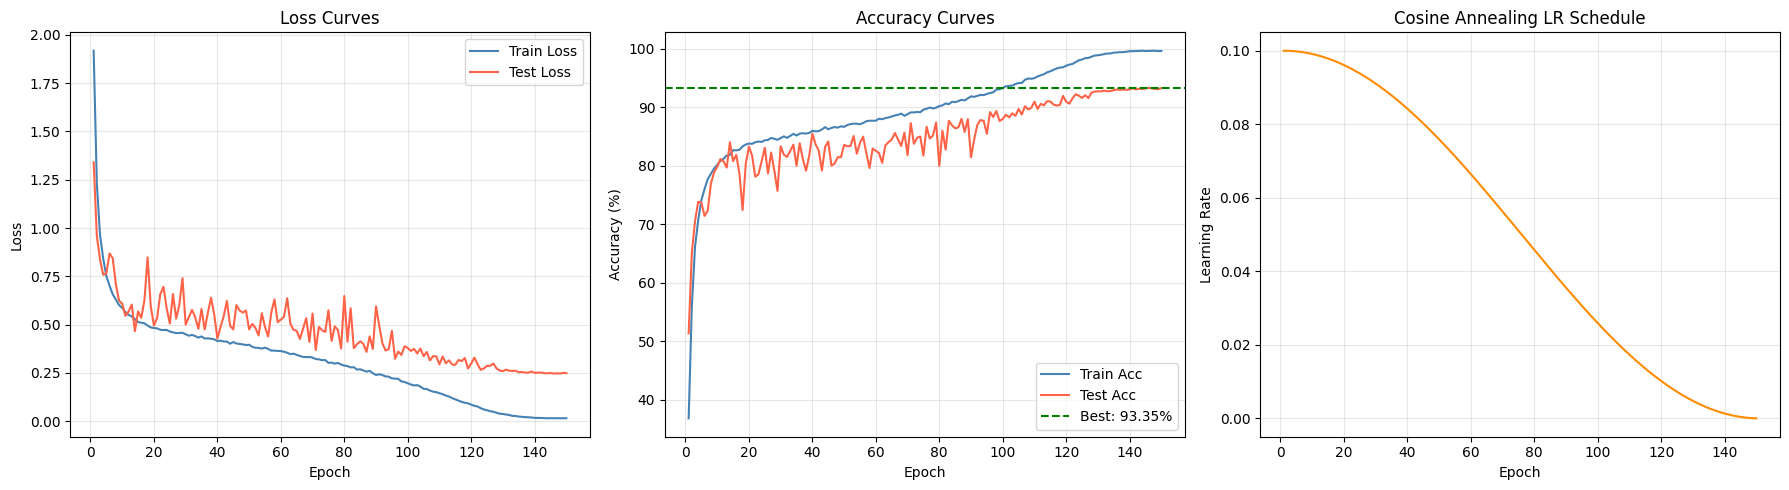

Figure saved to training_curves.png


In [ ]:
# ChatGPT assisted here a lot with the illustrations
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(epochs_range, train_losses, label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, test_losses,  label='Test Loss',  color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_range, train_accs, label='Train Acc', color='steelblue')
axes[1].plot(epochs_range, test_accs,  label='Test Acc',  color='tomato')
axes[1].axhline(best_acc, color='green', linestyle='--', label=f'Best: {best_acc:.2f}%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR schedule
axes[2].plot(epochs_range, lr_history, color='darkorange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Cosine Annealing LR Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to training_curves.png')

## Accuracy on Test Set

Breaks down which classes the model performs best/worst on.

Per-class accuracy on the test set:
----------------------------------------
airplane    : 95.4% (954/1000)
automobile  : 96.5% (965/1000)
bird        : 90.8% (908/1000)
cat         : 84.5% (845/1000)
deer        : 94.2% (942/1000)
dog         : 89.4% (894/1000)
frog        : 95.3% (953/1000)
horse       : 95.1% (951/1000)
ship        : 96.4% (964/1000)
truck       : 95.9% (959/1000)
----------------------------------------
  Overall     : 93.35%


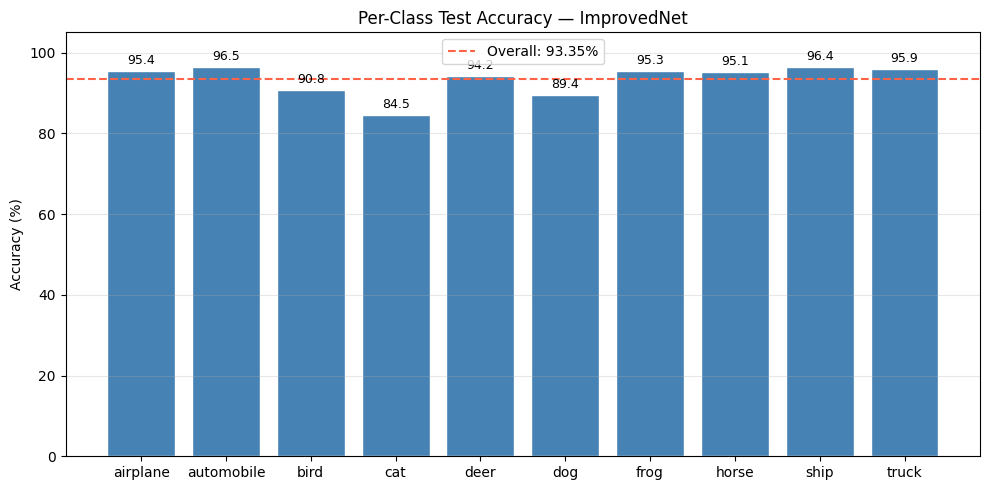

In [ ]:
# Load the best-saved model for final evaluation
model.load_state_dict(torch.load('improved_net_best.pt', map_location=device))
model.eval()

classes = testset.classes
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        for i in range(len(target)):
            label = target[i].item()
            class_correct[label] += (pred[i] == target[i]).item()
            class_total[label] += 1

print('Per-class accuracy on the test set:')
print('-' * 40)
for i, cls in enumerate(classes):
    acc = 100. * class_correct[i] / class_total[i]
    print(f'{cls:<12}: {acc:.1f}% ({class_correct[i]}/{class_total[i]})')
print('-' * 40)
overall = 100. * sum(class_correct) / sum(class_total)
print(f'  Overall     : {overall:.2f}%')

# Bar chart
accs = [100. * class_correct[i] / class_total[i] for i in range(10)]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(classes, accs, color='steelblue', edgecolor='white')
ax.axhline(overall, color='tomato', linestyle='--', label=f'Overall: {overall:.2f}%')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy — ImprovedNet')
ax.set_ylim(0, 105)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{a:.1f}', ha='center', va='bottom', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()